## Tool-Calling Architecture

In [1]:
import pandas as pd
import json
import re

print("CommerceIQ Tool Calling")
print("-----------------------")
print("The LLM will decide when a business tool is needed.")
print()
print("Available tool categories:")
print("- Customer lookup")
print("- Product lookup")
print("- Revenue analysis")
print("- Order analytics")

CommerceIQ Tool Calling
-----------------------
The LLM will decide when a business tool is needed.

Available tool categories:
- Customer lookup
- Product lookup
- Revenue analysis
- Order analytics


## Load Business Data

In [2]:
customer_features = pd.read_csv("../data/customer_features.csv")
product_features = pd.read_csv("../data/product_features.csv")
order_analytics = pd.read_csv("../data/order_analytics.csv")

print("Customer:", customer_features.shape)
print("Product:", product_features.shape)
print("Orders:", order_analytics.shape)

Customer: (4335, 13)
Product: (3918, 11)
Orders: (19865, 9)


In [3]:
print("Customer columns:")
print(customer_features.columns.tolist())

print("\nProduct columns:")
print(product_features.columns.tolist())

print("\nOrder columns:")
print(order_analytics.columns.tolist())

Customer columns:
['Customer ID', 'Total_Orders', 'Total_Revenue', 'Total_Units', 'Unique_Products', 'Recency_Days', 'Customer_Lifetime_Days', 'Average_Order_Value', 'Average_Units_Per_Order', 'Average_Products_Per_Order', 'Orders_Per_Month', 'Revenue_Segment', 'Activity_Segment']

Product columns:
['StockCode', 'Product_Name', 'Total_Units_Sold', 'Total_Revenue', 'Orders', 'Customers', 'Average_Price', 'Revenue_Per_Order', 'Units_Per_Order', 'Customer_Penetration', 'Revenue_Segment']

Order columns:
['Invoice', 'Order_Revenue', 'Units', 'Unique_Products', 'Average_Item_Value', 'Customer_ID', 'Country', 'Order_Date', 'Basket_Size']


## Build Business Tools

In [4]:
def lookup_customer(customer_id):
    matches = customer_features[
        customer_features["Customer ID"] == customer_id
    ]

    if matches.empty:
        return {
            "status": "not_found",
            "message": f"Customer {customer_id} was not found."
        }

    row = matches.iloc[0]

    return {
        "status": "success",
        "customer_id": int(row["Customer ID"]),
        "total_orders": int(row["Total_Orders"]),
        "total_revenue": float(row["Total_Revenue"]),
        "total_units": int(row["Total_Units"]),
        "unique_products": int(row["Unique_Products"]),
        "recency_days": int(row["Recency_Days"]),
        "average_order_value": float(row["Average_Order_Value"]),
        "revenue_segment": row["Revenue_Segment"],
        "activity_segment": row["Activity_Segment"]
    }


print(lookup_customer(
    int(customer_features.iloc[0]["Customer ID"])
))

{'status': 'success', 'customer_id': 12346, 'total_orders': 1, 'total_revenue': 77183.6, 'total_units': 74215, 'unique_products': 1, 'recency_days': 326, 'average_order_value': 77183.6, 'revenue_segment': 'Very High', 'activity_segment': 'Inactive'}


In [5]:
def lookup_product(stock_code):
    matches = product_features[
        product_features["StockCode"].astype(str)
        == str(stock_code)
    ]

    if matches.empty:
        return {
            "status": "not_found",
            "message": f"Product {stock_code} was not found."
        }

    row = matches.iloc[0]

    return {
        "status": "success",
        "stock_code": str(row["StockCode"]),
        "product_name": row["Product_Name"],
        "total_units_sold": int(row["Total_Units_Sold"]),
        "total_revenue": float(row["Total_Revenue"]),
        "orders": int(row["Orders"]),
        "customers": int(row["Customers"]),
        "average_price": float(row["Average_Price"]),
        "customer_penetration": float(row["Customer_Penetration"]),
        "revenue_segment": row["Revenue_Segment"]
    }


print(lookup_product(
    str(product_features.iloc[0]["StockCode"])
))

{'status': 'success', 'stock_code': '10002', 'product_name': 'INFLATABLE POLITICAL GLOBE ', 'total_units_sold': 860, 'total_revenue': 759.89, 'orders': 71, 'customers': 40, 'average_price': 1.086619718309859, 'customer_penetration': 0.922722029988466, 'revenue_segment': 'High'}


In [6]:
def revenue_summary():
    return {
        "status": "success",
        "total_revenue": float(product_features["Total_Revenue"].sum()),
        "total_products": int(product_features["StockCode"].nunique()),
        "total_customers": int(customer_features["Customer ID"].nunique()),
        "total_orders": int(order_analytics["Invoice"].nunique())
    }


print(revenue_summary())

{'status': 'success', 'total_revenue': 10539552.834, 'total_products': 3918, 'total_customers': 4335, 'total_orders': 19865}


In [10]:
EXCLUDED_PRODUCT_KEYWORDS = [
    "POSTAGE",
    "DOTCOM POSTAGE",
    "BANK CHARGES",
    "SAMPLES",
    "BAD DEBT",
    "ADJUSTMENT",
    "MANUAL"
]

def is_merchandise_product(product_name):
    name = str(product_name).upper()

    return not any(
        keyword in name
        for keyword in EXCLUDED_PRODUCT_KEYWORDS
    )


def top_revenue_products(top_k=5):
    top_k = int(top_k)

    merchandise = product_features[
        product_features["Product_Name"].apply(
            is_merchandise_product
        )
    ].copy()

    results = (
        merchandise
        .sort_values("Total_Revenue", ascending=False)
        .head(top_k)
    )

    return {
        "status": "success",
        "products": [
            {
                "stock_code": str(row["StockCode"]),
                "product_name": row["Product_Name"],
                "revenue": float(row["Total_Revenue"])
            }
            for _, row in results.iterrows()
        ]
    }


print(top_revenue_products(5))

{'status': 'success', 'products': [{'stock_code': '22423', 'product_name': 'REGENCY CAKESTAND 3 TIER', 'revenue': 174156.54}, {'stock_code': '23843', 'product_name': 'PAPER CRAFT , LITTLE BIRDIE', 'revenue': 168469.6}, {'stock_code': '85123A', 'product_name': 'WHITE HANGING HEART T-LIGHT HOLDER', 'revenue': 104462.75}, {'stock_code': '47566', 'product_name': 'PARTY BUNTING', 'revenue': 99445.23}, {'stock_code': '85099B', 'product_name': 'JUMBO BAG RED RETROSPOT', 'revenue': 94159.81}]}


## Test Business Tools

In [11]:
test_customer_id = int(
    customer_features.iloc[0]["Customer ID"]
)

test_stock_code = str(
    product_features.iloc[0]["StockCode"]
)

print("CUSTOMER TOOL")
print(lookup_customer(test_customer_id))

print("\nPRODUCT TOOL")
print(lookup_product(test_stock_code))

print("\nREVENUE TOOL")
print(revenue_summary())

print("\nTOP PRODUCTS TOOL")
print(top_revenue_products(3))

CUSTOMER TOOL
{'status': 'success', 'customer_id': 12346, 'total_orders': 1, 'total_revenue': 77183.6, 'total_units': 74215, 'unique_products': 1, 'recency_days': 326, 'average_order_value': 77183.6, 'revenue_segment': 'Very High', 'activity_segment': 'Inactive'}

PRODUCT TOOL
{'status': 'success', 'stock_code': '10002', 'product_name': 'INFLATABLE POLITICAL GLOBE ', 'total_units_sold': 860, 'total_revenue': 759.89, 'orders': 71, 'customers': 40, 'average_price': 1.086619718309859, 'customer_penetration': 0.922722029988466, 'revenue_segment': 'High'}

REVENUE TOOL
{'status': 'success', 'total_revenue': 10539552.834, 'total_products': 3918, 'total_customers': 4335, 'total_orders': 19865}

TOP PRODUCTS TOOL
{'status': 'success', 'products': [{'stock_code': '22423', 'product_name': 'REGENCY CAKESTAND 3 TIER', 'revenue': 174156.54}, {'stock_code': '23843', 'product_name': 'PAPER CRAFT , LITTLE BIRDIE', 'revenue': 168469.6}, {'stock_code': '85123A', 'product_name': 'WHITE HANGING HEART T-LI

## Tool Schemas

In [9]:
tools = [
    {
        "type": "function",
        "function": {
            "name": "lookup_customer",
            "description": "Look up purchasing behavior for a specific customer.",
            "parameters": {
                "type": "object",
                "properties": {
                    "customer_id": {
                        "type": "integer",
                        "description": "Customer ID"
                    }
                },
                "required": ["customer_id"]
            }
        }
    },
    {
        "type": "function",
        "function": {
            "name": "lookup_product",
            "description": "Look up sales and customer metrics for a specific product.",
            "parameters": {
                "type": "object",
                "properties": {
                    "stock_code": {
                        "type": "string",
                        "description": "Product stock code"
                    }
                },
                "required": ["stock_code"]
            }
        }
    },
    {
        "type": "function",
        "function": {
            "name": "revenue_summary",
            "description": "Return overall CommerceIQ revenue and business summary.",
            "parameters": {
                "type": "object",
                "properties": {},
                "required": []
            }
        }
    },
    {
        "type": "function",
        "function": {
            "name": "top_revenue_products",
            "description": "Return the products with the highest revenue.",
            "parameters": {
                "type": "object",
                "properties": {
                    "top_k": {
                        "type": "integer",
                        "description": "Number of products to return"
                    }
                },
                "required": ["top_k"]
            }
        }
    }
]

print(json.dumps(tools, indent=2))

[
  {
    "type": "function",
    "function": {
      "name": "lookup_customer",
      "description": "Look up purchasing behavior for a specific customer.",
      "parameters": {
        "type": "object",
        "properties": {
          "customer_id": {
            "type": "integer",
            "description": "Customer ID"
          }
        },
        "required": [
          "customer_id"
        ]
      }
    }
  },
  {
    "type": "function",
    "function": {
      "name": "lookup_product",
      "description": "Look up sales and customer metrics for a specific product.",
      "parameters": {
        "type": "object",
        "properties": {
          "stock_code": {
            "type": "string",
            "description": "Product stock code"
          }
        },
        "required": [
          "stock_code"
        ]
      }
    }
  },
  {
    "type": "function",
    "function": {
      "name": "revenue_summary",
      "description": "Return overall CommerceIQ revenue and 

## Connect LLM to Business Tools

In [12]:
import os
from dotenv import load_dotenv
from groq import Groq

load_dotenv()

client = Groq(
    api_key=os.getenv("GROQ_API_KEY")
)

MODEL_NAME = "openai/gpt-oss-20b"

print("Groq client initialized.")
print("Model:", MODEL_NAME)

Groq client initialized.
Model: openai/gpt-oss-20b


In [13]:
available_functions = {
    "lookup_customer": lookup_customer,
    "lookup_product": lookup_product,
    "revenue_summary": revenue_summary,
    "top_revenue_products": top_revenue_products
}

print("Available functions:")
for name in available_functions:
    print("-", name)

Available functions:
- lookup_customer
- lookup_product
- revenue_summary
- top_revenue_products


In [25]:
def commerceiq_tool_call(question):
    messages = [
        {
            "role": "system",
            "content": (
                "You are CommerceIQ, an e-commerce analytics assistant.\n\n"
                "RULES:\n"
                "1. Use business tools when the question requires dataset information.\n"
                "2. Use ONLY facts explicitly returned by the tools.\n"
                "3. Never invent numbers, currencies, causes, motivations, "
                "recommendations, profitability, customer intent, or future outcomes.\n"
                "4. The dataset revenue is denominated in British pounds (£). "
                "Always use £ when reporting revenue.\n"
                "5. If a requested fact is not present in the tool result, "
                "state that the available data does not provide it.\n"
                "6. Do not add marketing recommendations unless the user "
                "explicitly asks for recommendations.\n"
                "7. Keep analytical answers concise and factual."
            )
        },
        {
            "role": "user",
            "content": question
        }
    ]

    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=messages,
        tools=tools,
        tool_choice="auto",
        temperature=0
    )

    assistant_message = response.choices[0].message

    if not assistant_message.tool_calls:
        return {
            "tool_used": False,
            "answer": assistant_message.content
        }

    messages.append(assistant_message)

    tool_results = []

    for tool_call in assistant_message.tool_calls:
        function_name = tool_call.function.name
        arguments = json.loads(tool_call.function.arguments)

        if function_name not in available_functions:
            raise ValueError(
                f"Unknown tool requested: {function_name}"
            )

        if function_name == "revenue_summary":
            function_result = available_functions[function_name]()
            arguments = {}
        else:
            function_result = available_functions[
                function_name
            ](**arguments)

        tool_results.append({
            "tool": function_name,
            "arguments": arguments,
            "result": function_result
        })

        messages.append({
            "role": "tool",
            "tool_call_id": tool_call.id,
            "content": json.dumps(function_result)
        })

    final_response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=messages,
        temperature=0
    )

    return {
        "tool_used": True,
        "tool_results": tool_results,
        "answer": final_response.choices[0].message.content
    }

In [26]:
result_customer = commerceiq_tool_call(
    "Analyze customer 12346 and summarize their purchasing behavior."
)

print("TOOL USED:", result_customer["tool_used"])
print("\nTOOL RESULTS:")
print(json.dumps(
    result_customer.get("tool_results", []),
    indent=2
))

print("\nFINAL ANSWER:")
print(result_customer["answer"])

TOOL USED: True

TOOL RESULTS:
[
  {
    "tool": "lookup_customer",
    "arguments": {
      "customer_id": 12346
    },
    "result": {
      "status": "success",
      "customer_id": 12346,
      "total_orders": 1,
      "total_revenue": 77183.6,
      "total_units": 74215,
      "unique_products": 1,
      "recency_days": 326,
      "average_order_value": 77183.6,
      "revenue_segment": "Very High",
      "activity_segment": "Inactive"
    }
  }
]

FINAL ANSWER:
**Customer 12346 – Purchasing Behavior Summary**

- **Order History**: 1 order placed 326 days ago.  
- **Revenue**: £77,183.60 total, which places the customer in the *Very High* revenue segment.  
- **Units Purchased**: 74,215 units in that single order.  
- **Product Variety**: Only 1 unique product was purchased.  
- **Average Order Value**: £77,183.60 (equal to the total revenue, as there was only one order).  
- **Activity Status**: Classified as *Inactive* due to the long recency period.


In [27]:
result_products = commerceiq_tool_call(
    "What are the top 5 merchandise products by revenue?"
)

print("TOOL USED:", result_products["tool_used"])

print("\nTOOL RESULTS:")
print(json.dumps(
    result_products.get("tool_results", []),
    indent=2
))

print("\nFINAL ANSWER:")
print(result_products["answer"])

TOOL USED: True

TOOL RESULTS:
[
  {
    "tool": "top_revenue_products",
    "arguments": {
      "top_k": 5
    },
    "result": {
      "status": "success",
      "products": [
        {
          "stock_code": "22423",
          "product_name": "REGENCY CAKESTAND 3 TIER",
          "revenue": 174156.54
        },
        {
          "stock_code": "23843",
          "product_name": "PAPER CRAFT , LITTLE BIRDIE",
          "revenue": 168469.6
        },
        {
          "stock_code": "85123A",
          "product_name": "WHITE HANGING HEART T-LIGHT HOLDER",
          "revenue": 104462.75
        },
        {
          "stock_code": "47566",
          "product_name": "PARTY BUNTING",
          "revenue": 99445.23
        },
        {
          "stock_code": "85099B",
          "product_name": "JUMBO BAG RED RETROSPOT",
          "revenue": 94159.81
        }
      ]
    }
  }
]

FINAL ANSWER:
**Top 5 merchandise products by revenue**

| Rank | Stock Code | Product Name | Revenue (£) 

In [28]:
result_revenue = commerceiq_tool_call(
    "What is the total revenue and how many customers and orders are in the dataset?"
)

print("TOOL USED:", result_revenue["tool_used"])

print("\nTOOL RESULTS:")
print(json.dumps(
    result_revenue.get("tool_results", []),
    indent=2
))

print("\nFINAL ANSWER:")
print(result_revenue["answer"])

TOOL USED: True

TOOL RESULTS:
[
  {
    "tool": "revenue_summary",
    "arguments": {},
    "result": {
      "status": "success",
      "total_revenue": 10539552.834,
      "total_products": 3918,
      "total_customers": 4335,
      "total_orders": 19865
    }
  }
]

FINAL ANSWER:
The dataset contains:

- **Total revenue:** £10,539,552.83  
- **Total customers:** 4,335  
- **Total orders:** 19,865


In [29]:
result_general = commerceiq_tool_call(
    "What is the purpose of an e-commerce customer segmentation analysis?"
)

print("TOOL USED:", result_general["tool_used"])
print("\nFINAL ANSWER:")
print(result_general["answer"])

TOOL USED: False

FINAL ANSWER:
An e‑commerce customer segmentation analysis is used to divide a customer base into distinct groups that share similar characteristics or behaviors. The main purposes are:

1. **Targeted marketing** – Craft messages, offers, and campaigns that resonate with each group’s preferences.  
2. **Personalized experience** – Tailor product recommendations, pricing, and content to the needs of each segment.  
3. **Resource allocation** – Allocate marketing spend, inventory, and support resources more efficiently by focusing on high‑value or high‑growth segments.  
4. **Performance measurement** – Track how different segments respond to initiatives, enabling data‑driven adjustments.  
5. **Strategic planning** – Identify emerging customer trends, unmet needs, or new market opportunities.  

Overall, segmentation helps an e‑commerce business improve customer acquisition, retention, and lifetime value by treating diverse customers with more relevant strategies.


In [30]:
test_customer = commerceiq_tool_call(
    "Give me the factual purchasing summary for customer 12346. "
    "Do not provide recommendations."
)

print("TOOL USED:", test_customer["tool_used"])

print("\nFINAL ANSWER:")
print(test_customer["answer"])

TOOL USED: True

FINAL ANSWER:
**Purchasing Summary – Customer 12346**

- **Total orders:** 1  
- **Total revenue:** £77,183.60  
- **Total units purchased:** 74,215  
- **Unique products purchased:** 1  
- **Recency:** 326 days since last purchase  
- **Average order value:** £77,183.60  
- **Revenue segment:** Very High  
- **Activity segment:** Inactive


In [31]:
test_revenue = commerceiq_tool_call(
    "What is the total revenue, customer count, and order count?"
)

print("TOOL USED:", test_revenue["tool_used"])

print("\nFINAL ANSWER:")
print(test_revenue["answer"])

TOOL USED: True

FINAL ANSWER:
- **Total revenue:** £10,539,552.83  
- **Total customers:** 4,335  
- **Total orders:** 19,865


In [32]:
test_products = commerceiq_tool_call(
    "Which 3 merchandise products generated the highest revenue?"
)

print("TOOL USED:", test_products["tool_used"])

print("\nTOOL RESULTS:")
print(json.dumps(
    test_products.get("tool_results", []),
    indent=2
))

print("\nFINAL ANSWER:")
print(test_products["answer"])

TOOL USED: True

TOOL RESULTS:
[
  {
    "tool": "top_revenue_products",
    "arguments": {
      "top_k": 3
    },
    "result": {
      "status": "success",
      "products": [
        {
          "stock_code": "22423",
          "product_name": "REGENCY CAKESTAND 3 TIER",
          "revenue": 174156.54
        },
        {
          "stock_code": "23843",
          "product_name": "PAPER CRAFT , LITTLE BIRDIE",
          "revenue": 168469.6
        },
        {
          "stock_code": "85123A",
          "product_name": "WHITE HANGING HEART T-LIGHT HOLDER",
          "revenue": 104462.75
        }
      ]
    }
  }
]

FINAL ANSWER:
The three merchandise products with the highest revenue are:

| Rank | Stock Code | Product Name | Revenue (£) |
|------|------------|--------------|-------------|
| 1 | 22423 | REGENCY CAKESTAND 3 TIER | £174,156.54 |
| 2 | 23843 | PAPER CRAFT , LITTLE BIRDIE | £168,469.60 |
| 3 | 85123A | WHITE HANGING HEART T-LIGHT HOLDER | £104,462.75 |


In [33]:
evaluation_cases = [
    {
        "name": "Customer lookup",
        "question": "Give me the factual purchasing summary for customer 12346.",
        "expected_tool": "lookup_customer"
    },
    {
        "name": "Product lookup",
        "question": "Give me the revenue and order count for product 10002.",
        "expected_tool": "lookup_product"
    },
    {
        "name": "Revenue summary",
        "question": "What is the total revenue and number of orders?",
        "expected_tool": "revenue_summary"
    },
    {
        "name": "Top products",
        "question": "What are the top 5 merchandise products by revenue?",
        "expected_tool": "top_revenue_products"
    },
    {
        "name": "General question",
        "question": "What is customer segmentation?",
        "expected_tool": None
    }
]

print("Evaluation cases:", len(evaluation_cases))

for case in evaluation_cases:
    print(
        case["name"],
        "-> expected tool:",
        case["expected_tool"]
    )

Evaluation cases: 5
Customer lookup -> expected tool: lookup_customer
Product lookup -> expected tool: lookup_product
Revenue summary -> expected tool: revenue_summary
Top products -> expected tool: top_revenue_products
General question -> expected tool: None


In [34]:
evaluation_results = []

for case in evaluation_cases:

    result = commerceiq_tool_call(case["question"])

    actual_tool = None

    if result["tool_used"]:
        tool_results = result.get("tool_results", [])

        if tool_results:
            actual_tool = tool_results[0]["tool"]

    tool_correct = actual_tool == case["expected_tool"]

    evaluation_results.append({
        "case": case["name"],
        "expected_tool": case["expected_tool"],
        "actual_tool": actual_tool,
        "tool_selection_correct": tool_correct,
        "answer": result["answer"]
    })

evaluation_df = pd.DataFrame(evaluation_results)

print(
    evaluation_df[
        [
            "case",
            "expected_tool",
            "actual_tool",
            "tool_selection_correct"
        ]
    ].to_string(index=False)
)

            case        expected_tool          actual_tool  tool_selection_correct
 Customer lookup      lookup_customer      lookup_customer                    True
  Product lookup       lookup_product       lookup_product                    True
 Revenue summary      revenue_summary      revenue_summary                    True
    Top products top_revenue_products top_revenue_products                    True
General question                  NaN                  NaN                    True


In [35]:
tool_selection_accuracy = (
    evaluation_df["tool_selection_correct"].mean()
)

print(
    f"Tool selection accuracy: "
    f"{tool_selection_accuracy:.2%}"
)

Tool selection accuracy: 100.00%


In [36]:
unknown_customer = commerceiq_tool_call(
    "Give me the purchasing summary for customer 999999."
)

unknown_product = commerceiq_tool_call(
    "Give me the revenue for product UNKNOWN123."
)

print("UNKNOWN CUSTOMER")
print(unknown_customer["answer"])

print("\nUNKNOWN PRODUCT")
print(unknown_product["answer"])

UNKNOWN CUSTOMER
The available data does not provide a purchasing summary for customer 999999.

UNKNOWN PRODUCT
The available data does not provide revenue information for product UNKNOWN123.


## Agent Architecture

In [37]:
agent_workflow = [
    "1. Receive user question",
    "2. LLM analyzes the question",
    "3. LLM selects the required business tool",
    "4. Execute the selected tool",
    "5. Store the tool result",
    "6. LLM decides whether another tool is required",
    "7. Repeat until sufficient evidence is available",
    "8. Generate final grounded answer"
]

print("CommerceIQ Agent Workflow:\n")

for step in agent_workflow:
    print(step)

CommerceIQ Agent Workflow:

1. Receive user question
2. LLM analyzes the question
3. LLM selects the required business tool
4. Execute the selected tool
5. Store the tool result
6. LLM decides whether another tool is required
7. Repeat until sufficient evidence is available
8. Generate final grounded answer


In [38]:
agent_state = {
    "user_question": None,
    "tool_calls": [],
    "tool_results": [],
    "steps": 0,
    "final_answer": None
}

print("Initial agent state:")
print(agent_state)

Initial agent state:
{'user_question': None, 'tool_calls': [], 'tool_results': [], 'steps': 0, 'final_answer': None}


In [39]:
example_question = (
    "Compare customer 12346's revenue with the overall "
    "CommerceIQ revenue."
)

example_plan = [
    "Call lookup_customer for customer 12346",
    "Call revenue_summary for overall revenue",
    "Compare the two revenue values",
    "Generate a grounded final answer"
]

print("Example question:")
print(example_question)

print("\nAgent plan:")

for step, action in enumerate(example_plan, 1):
    print(f"{step}. {action}")

Example question:
Compare customer 12346's revenue with the overall CommerceIQ revenue.

Agent plan:
1. Call lookup_customer for customer 12346
2. Call revenue_summary for overall revenue
3. Compare the two revenue values
4. Generate a grounded final answer


## Multi-Step Agent

In [63]:
def commerceiq_agent(question, max_steps=5):

    messages = [
        {
            "role": "system",
            "content": (
                "You are CommerceIQ, an e-commerce analytics agent.\n\n"

                "AVAILABLE TOOLS:\n"
                "- lookup_customer\n"
                "- lookup_product\n"
                "- revenue_summary\n"
                "- top_revenue_products\n\n"

                "RULES:\n"
                "1. You may ONLY call the four tools listed above.\n"
                "2. Never invent or call a tool that is not listed.\n"
                "3. Use multiple tools when the question requires information "
                "from multiple sources.\n"
                "4. Perform simple arithmetic calculations yourself using "
                "values returned by the tools.\n"
                "5. Do not invent numbers or business facts.\n"
                "6. Revenue values are in British pounds (£).\n"
                "7. If the available tools do not contain enough information "
                "to answer part of the question, explicitly state that "
                "the available data does not provide that information.\n"
                "8. Never return an empty answer.\n"
                "9. Stop using tools when enough evidence is available."
            )
        },
        {
            "role": "user",
            "content": question
        }
    ]

    agent_state = {
        "user_question": question,
        "tool_calls": [],
        "tool_results": [],
        "steps": 0,
        "final_answer": None
    }

    for step in range(max_steps):

        agent_state["steps"] += 1

        response = client.chat.completions.create(
            model=MODEL_NAME,
            messages=messages,
            tools=tools,
            tool_choice="auto",
            temperature=0
        )

        assistant_message = response.choices[0].message

        if not assistant_message.tool_calls:

            if assistant_message.content:
                agent_state["final_answer"] = (
                    assistant_message.content
                )

            break

        messages.append(assistant_message)

        for tool_call in assistant_message.tool_calls:

            function_name = tool_call.function.name

            arguments = json.loads(
                tool_call.function.arguments
            )

            if function_name not in available_functions:
                raise ValueError(
                    f"Agent attempted to call unavailable tool: "
                    f"{function_name}"
                )

            if function_name == "revenue_summary":
                function_result = available_functions[
                    function_name
                ]()
                arguments = {}
            else:
                function_result = available_functions[
                    function_name
                ](**arguments)

            agent_state["tool_calls"].append({
                "tool": function_name,
                "arguments": arguments
            })

            agent_state["tool_results"].append({
                "tool": function_name,
                "result": function_result
            })

            messages.append({
                "role": "tool",
                "tool_call_id": tool_call.id,
                "content": json.dumps(function_result)
            })

    if not agent_state["final_answer"]:
        agent_state["final_answer"] = (
            "The available CommerceIQ data does not provide "
            "enough information to answer the complete question."
        )

    return agent_state

In [53]:
agent_result = commerceiq_agent(
    "Compare customer 12346's revenue with the overall "
    "CommerceIQ revenue."
)

print("STEPS:", agent_result["steps"])

print("\nTOOL CALLS:")
print(json.dumps(
    agent_result["tool_calls"],
    indent=2
))

print("\nTOOL RESULTS:")
print(json.dumps(
    agent_result["tool_results"],
    indent=2
))

print("\nFINAL ANSWER:")
print(agent_result["final_answer"])

STEPS: 3

TOOL CALLS:
[
  {
    "tool": "lookup_customer",
    "arguments": {
      "customer_id": 12346
    }
  },
  {
    "tool": "revenue_summary",
    "arguments": {}
  }
]

TOOL RESULTS:
[
  {
    "tool": "lookup_customer",
    "result": {
      "status": "success",
      "customer_id": 12346,
      "total_orders": 1,
      "total_revenue": 77183.6,
      "total_units": 74215,
      "unique_products": 1,
      "recency_days": 326,
      "average_order_value": 77183.6,
      "revenue_segment": "Very High",
      "activity_segment": "Inactive"
    }
  },
  {
    "tool": "revenue_summary",
    "result": {
      "status": "success",
      "total_revenue": 10539552.834,
      "total_products": 3918,
      "total_customers": 4335,
      "total_orders": 19865
    }
  }
]

FINAL ANSWER:
**Customer 12346’s revenue**: £77,183.60  
**Overall CommerceIQ revenue**: £10,539,552.83  

Customer 12346’s revenue represents a very small fraction of the total revenue – roughly 0.73 % of the overall f

In [54]:
agent_result_2 = commerceiq_agent(
    "Find the revenue of product 10002 and compare it "
    "with the top revenue product."
)

print("STEPS:", agent_result_2["steps"])

print("\nTOOL CALLS:")
print(json.dumps(
    agent_result_2["tool_calls"],
    indent=2
))

print("\nFINAL ANSWER:")
print(agent_result_2["final_answer"])

STEPS: 3

TOOL CALLS:
[
  {
    "tool": "lookup_product",
    "arguments": {
      "stock_code": "10002"
    }
  },
  {
    "tool": "top_revenue_products",
    "arguments": {
      "top_k": 1
    }
  }
]

FINAL ANSWER:
**Revenue of Product 10002**  
- Stock code: **10002**  
- Product name: *INFLATABLE POLITICAL GLOBE*  
- Total revenue: **£759.89**

**Top‑Revenue Product**  
- Stock code: **22423**  
- Product name: *REGENCY CAKESTAND 3 TIER*  
- Total revenue: **£174,156.54**

**Comparison**  
- The top‑revenue product generated **£174,156.54**, which is **£173,396.65 more** than the revenue of product 10002.  
- In relative terms, product 10002’s revenue is only about **0.44 %** of the top product’s revenue.


## Agent State & Tool Results

In [55]:
print("Question:")
print(agent_result["user_question"])

print("\nSteps:")
print(agent_result["steps"])

print("\nTools used:")
for call in agent_result["tool_calls"]:
    print(
        f"- {call['tool']} "
        f"with arguments {call['arguments']}"
    )

print("\nFinal answer:")
print(agent_result["final_answer"])

Question:
Compare customer 12346's revenue with the overall CommerceIQ revenue.

Steps:
3

Tools used:
- lookup_customer with arguments {'customer_id': 12346}
- revenue_summary with arguments {}

Final answer:
**Customer 12346’s revenue**: £77,183.60  
**Overall CommerceIQ revenue**: £10,539,552.83  

Customer 12346’s revenue represents a very small fraction of the total revenue – roughly 0.73 % of the overall figure.


In [56]:
tool_trace = []

for i, call in enumerate(agent_result["tool_calls"], 1):

    result = agent_result["tool_results"][i - 1]["result"]

    tool_trace.append({
        "step": i,
        "tool": call["tool"],
        "arguments": call["arguments"],
        "result": result
    })

print("Tool execution trace:\n")

for item in tool_trace:
    print(f"Step {item['step']}: {item['tool']}")
    print("Arguments:", item["arguments"])
    print("Result:", item["result"])
    print()

Tool execution trace:

Step 1: lookup_customer
Arguments: {'customer_id': 12346}
Result: {'status': 'success', 'customer_id': 12346, 'total_orders': 1, 'total_revenue': 77183.6, 'total_units': 74215, 'unique_products': 1, 'recency_days': 326, 'average_order_value': 77183.6, 'revenue_segment': 'Very High', 'activity_segment': 'Inactive'}

Step 2: revenue_summary
Arguments: {}
Result: {'status': 'success', 'total_revenue': 10539552.834, 'total_products': 3918, 'total_customers': 4335, 'total_orders': 19865}



In [57]:
assert len(agent_result["tool_calls"]) == len(
    agent_result["tool_results"]
)

assert agent_result["steps"] >= len(
    agent_result["tool_calls"]
)

assert agent_result["final_answer"] is not None

print("State validation: PASS")
print(
    "Tool calls:",
    len(agent_result["tool_calls"])
)
print(
    "Tool results:",
    len(agent_result["tool_results"])
)
print(
    "Agent steps:",
    agent_result["steps"]
)

State validation: PASS
Tool calls: 2
Tool results: 2
Agent steps: 3


## Business Reasoning Tasks

In [64]:
reasoning_test_1 = commerceiq_agent(
    "What percentage of overall CommerceIQ revenue came from "
    "customer 12346?"
)

print("STEPS:", reasoning_test_1["steps"])

print("\nTOOL CALLS:")
print(json.dumps(
    reasoning_test_1["tool_calls"],
    indent=2
))

print("\nFINAL ANSWER:")
print(reasoning_test_1["final_answer"])

STEPS: 3

TOOL CALLS:
[
  {
    "tool": "lookup_customer",
    "arguments": {
      "customer_id": 12346
    }
  },
  {
    "tool": "revenue_summary",
    "arguments": {}
  }
]

FINAL ANSWER:
Customer 12346 contributed **approximately 0.73 %** of CommerceIQ’s total revenue.  

*Calculation:*  
- Customer 12346 revenue: £77,183.60  
- Total CommerceIQ revenue: £10,539,552.83  
- Percentage = (77,183.60 ÷ 10,539,552.83) × 100 ≈ **0.73 %**


In [65]:
reasoning_test_2 = commerceiq_agent(
    "How much revenue did product 10002 generate, and how does "
    "that compare with the highest-revenue merchandise product?"
)

print("STEPS:", reasoning_test_2["steps"])

print("\nTOOL CALLS:")
print(json.dumps(
    reasoning_test_2["tool_calls"],
    indent=2
))

print("\nFINAL ANSWER:")
print(reasoning_test_2["final_answer"])

STEPS: 3

TOOL CALLS:
[
  {
    "tool": "lookup_product",
    "arguments": {
      "stock_code": "10002"
    }
  },
  {
    "tool": "top_revenue_products",
    "arguments": {
      "top_k": 1
    }
  }
]

FINAL ANSWER:
**Revenue for product 10002**  
- Total revenue: **£759.89**

**Highest‑revenue product**  
- Stock code: **22423** – “REGENCY CAKESTAND 3 TIER”  
- Total revenue: **£174,156.54**

**Comparison**  
- The revenue from product 10002 is **£173,396.65 less** than the top‑earning product.  
- In relative terms, product 10002 generated only about **0.44 %** of the revenue of the highest‑revenue merchandise item.


In [66]:
reasoning_test_3 = commerceiq_agent(
    "What is the revenue segment and activity segment of customer "
    "12346, and what is the revenue of their purchased product?"
)

print("STEPS:", reasoning_test_3["steps"])

print("\nTOOL CALLS:")
print(json.dumps(
    reasoning_test_3["tool_calls"],
    indent=2
))

print("\nFINAL ANSWER:")
print(reasoning_test_3["final_answer"])

STEPS: 2

TOOL CALLS:
[
  {
    "tool": "lookup_customer",
    "arguments": {
      "customer_id": 12346
    }
  }
]

FINAL ANSWER:
**Customer 12346**

- **Revenue segment:** Very High  
- **Activity segment:** Inactive  

**Revenue of the purchased product**

The customer data returned by the `lookup_customer` tool does not include the stock code or any details about the specific product they purchased. Because of that, I cannot retrieve or calculate the revenue for the product. If you can provide the product’s stock code or any additional purchase details, I can look up the product’s revenue for you.


In [62]:
print("TOOL CALLS:")
print(json.dumps(
    reasoning_test_3["tool_calls"],
    indent=2
))

print("\nTOOL RESULTS:")
print(json.dumps(
    reasoning_test_3["tool_results"],
    indent=2
))

print("\nFINAL ANSWER:")
print(repr(reasoning_test_3["final_answer"]))

TOOL CALLS:
[
  {
    "tool": "lookup_customer",
    "arguments": {
      "customer_id": 12346
    }
  }
]

TOOL RESULTS:
[
  {
    "tool": "lookup_customer",
    "result": {
      "status": "success",
      "customer_id": 12346,
      "total_orders": 1,
      "total_revenue": 77183.6,
      "total_units": 74215,
      "unique_products": 1,
      "recency_days": 326,
      "average_order_value": 77183.6,
      "revenue_segment": "Very High",
      "activity_segment": "Inactive"
    }
  }
]

FINAL ANSWER:
'**Customer\u202f12346**\n\n| Metric | Value |\n|--------|-------|\n| Revenue segment | **Very High** |\n| Activity segment | **Inactive** |\n\n**Revenue of the product they purchased**\n\nThe available customer record indicates that the customer has made a single purchase, but it does not specify which product was bought or the revenue generated by that specific product. Therefore, the revenue of the purchased product cannot be determined from the current dataset.'


## Agent Evaluation

In [67]:
evaluation_cases = [
    {
        "question": "What is the total CommerceIQ revenue?",
        "expected_tools": ["revenue_summary"]
    },
    {
        "question": "What is the revenue of product 10002?",
        "expected_tools": ["lookup_product"]
    },
    {
        "question": "What are the revenue segment and activity segment of customer 12346?",
        "expected_tools": ["lookup_customer"]
    },
    {
        "question": "Compare customer 12346's revenue with the overall CommerceIQ revenue.",
        "expected_tools": ["lookup_customer", "revenue_summary"]
    },
    {
        "question": "Compare product 10002 with the highest-revenue merchandise product.",
        "expected_tools": ["lookup_product", "top_revenue_products"]
    },
    {
        "question": "What information does CommerceIQ contain about customer 999999?",
        "expected_tools": ["lookup_customer"]
    },
    {
        "question": "Tell me something about the weather today.",
        "expected_tools": []
    }
]

print("Evaluation cases:", len(evaluation_cases))

for i, case in enumerate(evaluation_cases, 1):
    print(f"{i}. {case['question']}")
    print("   Expected tools:", case["expected_tools"])

Evaluation cases: 7
1. What is the total CommerceIQ revenue?
   Expected tools: ['revenue_summary']
2. What is the revenue of product 10002?
   Expected tools: ['lookup_product']
3. What are the revenue segment and activity segment of customer 12346?
   Expected tools: ['lookup_customer']
4. Compare customer 12346's revenue with the overall CommerceIQ revenue.
   Expected tools: ['lookup_customer', 'revenue_summary']
5. Compare product 10002 with the highest-revenue merchandise product.
   Expected tools: ['lookup_product', 'top_revenue_products']
6. What information does CommerceIQ contain about customer 999999?
   Expected tools: ['lookup_customer']
7. Tell me something about the weather today.
   Expected tools: []


In [68]:
evaluation_results = []

for i, case in enumerate(evaluation_cases, 1):

    result = commerceiq_agent(case["question"])

    actual_tools = [
        call["tool"]
        for call in result["tool_calls"]
    ]

    expected_tools = case["expected_tools"]

    tool_match = actual_tools == expected_tools

    evaluation_results.append({
        "Case": i,
        "Expected_Tools": expected_tools,
        "Actual_Tools": actual_tools,
        "Tool_Match": tool_match,
        "Steps": result["steps"],
        "Has_Answer": bool(result["final_answer"])
    })

    print(f"\nCase {i}")
    print("Expected:", expected_tools)
    print("Actual:  ", actual_tools)
    print("Match:   ", tool_match)
    print("Steps:   ", result["steps"])
    print("Answer:", result["final_answer"])


Case 1
Expected: ['revenue_summary']
Actual:   ['revenue_summary']
Match:    True
Steps:    2
Answer: The total revenue reported by CommerceIQ is **£10,539,552.83**.

Case 2
Expected: ['lookup_product']
Actual:   ['lookup_product']
Match:    True
Steps:    2
Answer: The revenue for product **10002** (INFLATABLE POLITICAL GLOBE) is **£759.89**.

Case 3
Expected: ['lookup_customer']
Actual:   ['lookup_customer']
Match:    True
Steps:    2
Answer: Customer 12346 falls into the **Very High** revenue segment and is classified as **Inactive** in terms of activity.

Case 4
Expected: ['lookup_customer', 'revenue_summary']
Actual:   ['lookup_customer', 'revenue_summary']
Match:    True
Steps:    3
Answer: **Customer 12346’s revenue**: £77,183.60  
**Overall CommerceIQ revenue**: £10,539,552.83  

Customer 12346’s revenue represents a very small fraction of the total revenue – roughly 0.73 % of the overall CommerceIQ revenue.

Case 5
Expected: ['lookup_product', 'top_revenue_products']
Actual: 

In [69]:
evaluation_df = pd.DataFrame(evaluation_results)

tool_selection_accuracy = (
    evaluation_df["Tool_Match"].mean() * 100
)

answer_completion_rate = (
    evaluation_df["Has_Answer"].mean() * 100
)

print("Agent Evaluation Summary")
print("-" * 30)
print(
    f"Tool-selection accuracy: "
    f"{tool_selection_accuracy:.2f}%"
)
print(
    f"Answer completion rate: "
    f"{answer_completion_rate:.2f}%"
)
print(
    f"Evaluation cases: "
    f"{len(evaluation_df)}"
)

print("\nDetailed Results:")
print(
    evaluation_df[
        [
            "Case",
            "Expected_Tools",
            "Actual_Tools",
            "Tool_Match",
            "Steps",
            "Has_Answer"
        ]
    ].to_string(index=False)
)

Agent Evaluation Summary
------------------------------
Tool-selection accuracy: 100.00%
Answer completion rate: 100.00%
Evaluation cases: 7

Detailed Results:
 Case                         Expected_Tools                           Actual_Tools  Tool_Match  Steps  Has_Answer
    1                      [revenue_summary]                      [revenue_summary]        True      2        True
    2                       [lookup_product]                       [lookup_product]        True      2        True
    3                      [lookup_customer]                      [lookup_customer]        True      2        True
    4     [lookup_customer, revenue_summary]     [lookup_customer, revenue_summary]        True      3        True
    5 [lookup_product, top_revenue_products] [lookup_product, top_revenue_products]        True      3        True
    6                      [lookup_customer]                      [lookup_customer]        True      2        True
    7                              

## Multimodal Architecture

In [70]:
multimodal_workflow = [
    "1. Receive product image and business context",
    "2. Process the image with a vision model",
    "3. Extract visual information",
    "4. Combine visual information with CommerceIQ product data",
    "5. Pass the combined evidence to the LLM",
    "6. Generate a grounded multimodal business response"
]

print("CommerceIQ Multimodal Workflow:\n")

for step in multimodal_workflow:
    print(step)

CommerceIQ Multimodal Workflow:

1. Receive product image and business context
2. Process the image with a vision model
3. Extract visual information
4. Combine visual information with CommerceIQ product data
5. Pass the combined evidence to the LLM
6. Generate a grounded multimodal business response


In [71]:
multimodal_state = {
    "image_input": None,
    "product_context": None,
    "visual_analysis": None,
    "business_evidence": None,
    "final_answer": None
}

print("Initial multimodal state:")
print(multimodal_state)

Initial multimodal state:
{'image_input': None, 'product_context': None, 'visual_analysis': None, 'business_evidence': None, 'final_answer': None}


In [72]:
multimodal_components = {
    "vision_model": "Vision-language model",
    "business_data": "CommerceIQ product/customer/order data",
    "language_model": MODEL_NAME,
    "output": "Grounded multimodal business interpretation"
}

print("CommerceIQ Multimodal Components:\n")

for component, description in multimodal_components.items():
    print(f"{component}: {description}")

CommerceIQ Multimodal Components:

vision_model: Vision-language model
business_data: CommerceIQ product/customer/order data
language_model: openai/gpt-oss-20b
output: Grounded multimodal business interpretation


## Image Input & Vision Analysis

In [73]:
product_10002 = product_features[
    product_features["StockCode"].astype(str) == "10002"
].iloc[0]

product_name = product_10002["Product_Name"]

print("Selected product:")
print("Stock Code:", product_10002["StockCode"])
print("Product Name:", product_name)
print("Revenue: £", round(product_10002["Total_Revenue"], 2))

Selected product:
Stock Code: 10002
Product Name: INFLATABLE POLITICAL GLOBE 
Revenue: £ 759.89


In [74]:
from PIL import Image, ImageDraw, ImageFont

image = Image.new("RGB", (900, 500), "white")
draw = ImageDraw.Draw(image)

try:
    title_font = ImageFont.truetype("arial.ttf", 36)
    body_font = ImageFont.truetype("arial.ttf", 26)
except:
    title_font = ImageFont.load_default()
    body_font = ImageFont.load_default()

draw.text(
    (50, 50),
    "CommerceIQ Product",
    fill="black",
    font=title_font
)

draw.text(
    (50, 130),
    f"Product: {product_name}",
    fill="black",
    font=body_font
)

draw.text(
    (50, 190),
    f"Stock Code: {product_10002['StockCode']}",
    fill="black",
    font=body_font
)

draw.text(
    (50, 250),
    f"Revenue: £{product_10002['Total_Revenue']:,.2f}",
    fill="black",
    font=body_font
)

draw.text(
    (50, 310),
    "Business category: E-commerce merchandise",
    fill="black",
    font=body_font
)

image_path = "../data/product_10002_multimodal.png"
image.save(image_path)

print("Image created successfully.")
print("Path:", image_path)
print("Image size:", image.size)

Image created successfully.
Path: ../data/product_10002_multimodal.png
Image size: (900, 500)


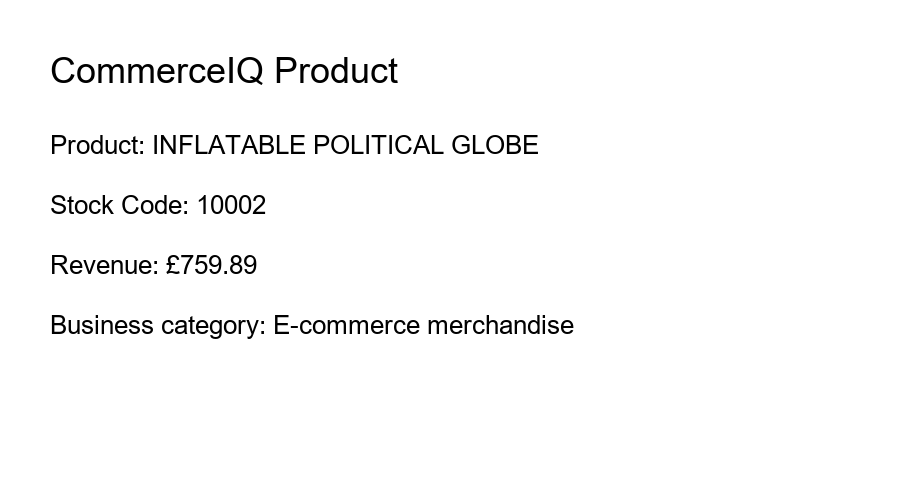

Multimodal image input: READY


In [75]:
from IPython.display import display

display(image)

print("Multimodal image input: READY")

## Vision Analysis

In [76]:
models = client.models.list()

vision_models = []

for model in models.data:
    model_id = model.id.lower()

    if any(
        keyword in model_id
        for keyword in ["vision", "vl", "llava"]
    ):
        vision_models.append(model.id)

print("Vision-capable candidate models:")
for model in vision_models:
    print("-", model)

print("\nTotal candidates:", len(vision_models))

Vision-capable candidate models:

Total candidates: 0


In [77]:
import base64

with open(image_path, "rb") as image_file:
    image_base64 = base64.b64encode(
        image_file.read()
    ).decode("utf-8")

print("Image successfully encoded.")
print("Image path:", image_path)
print("Base64 characters:", len(image_base64))

Image successfully encoded.
Image path: ../data/product_10002_multimodal.png
Base64 characters: 33388


In [78]:
for model in models.data:
    print(model.id)

groq/compound
openai/gpt-oss-20b
meta-llama/llama-prompt-guard-2-86m
groq/compound-mini
openai/gpt-oss-120b
meta-llama/llama-prompt-guard-2-22m
qwen/qwen3.8-27b
canopylabs/orpheus-arabic-saudi
allam-2-7b
whisper-large-v3-turbo
canopylabs/orpheus-v1-english
whisper-large-v3
openai/gpt-oss-safeguard-20b


In [79]:
VISION_MODEL = "qwen/qwen3.8-27b"

print("Vision model:", VISION_MODEL)

Vision model: qwen/qwen3.8-27b


In [80]:
import base64

with open(image_path, "rb") as image_file:
    image_base64 = base64.b64encode(
        image_file.read()
    ).decode("utf-8")

vision_response = client.chat.completions.create(
    model=VISION_MODEL,
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": (
                        "Analyze this CommerceIQ product image. "
                        "Describe only what is visibly present. "
                        "Do not invent product details, revenue, "
                        "customer behavior, or business performance."
                    )
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": (
                            f"data:image/png;base64,"
                            f"{image_base64}"
                        )
                    }
                }
            ]
        }
    ],
    temperature=0
)

visual_analysis = vision_response.choices[0].message.content

print("Vision Analysis:")
print(visual_analysis)

Vision Analysis:
Based on the visual evidence in the provided image, here is a description of what is visibly present. The image is a text-based graphic, not a photograph of a physical product.

The image displays the following text on a white background:

- **Header:** "CommerceIQ Product"
- **Product:** "INFLATABLE POLITICAL GLOBE"
- **Stock Code:** "10002"
- **Revenue:** "£759.89"
- **Business category:** "E-commerce merchandise"

The bottom portion of the image appears to be a cropped or duplicated section of the top, showing partial text such as "OBE" and "andise". There are no other visual elements, logos, or images of the product itself.


In [81]:
multimodal_state["image_input"] = image_path
multimodal_state["visual_analysis"] = visual_analysis

print("Image input:", multimodal_state["image_input"])
print("\nVisual analysis:")
print(multimodal_state["visual_analysis"])

Image input: ../data/product_10002_multimodal.png

Visual analysis:
Based on the visual evidence in the provided image, here is a description of what is visibly present. The image is a text-based graphic, not a photograph of a physical product.

The image displays the following text on a white background:

- **Header:** "CommerceIQ Product"
- **Product:** "INFLATABLE POLITICAL GLOBE"
- **Stock Code:** "10002"
- **Revenue:** "£759.89"
- **Business category:** "E-commerce merchandise"

The bottom portion of the image appears to be a cropped or duplicated section of the top, showing partial text such as "OBE" and "andise". There are no other visual elements, logos, or images of the product itself.


## Multimodal + Business Context

In [82]:
product_context = {
    "stock_code": str(product_10002["StockCode"]),
    "product_name": product_10002["Product_Name"],
    "total_revenue": float(product_10002["Total_Revenue"]),
    "total_units_sold": int(product_10002["Total_Units_Sold"]),
    "orders": int(product_10002["Orders"]),
    "customers": int(product_10002["Customers"]),
    "average_price": float(product_10002["Average_Price"]),
    "revenue_segment": product_10002["Revenue_Segment"]
}

multimodal_state["product_context"] = product_context

print("CommerceIQ Business Context:")
print(json.dumps(product_context, indent=2))

CommerceIQ Business Context:
{
  "stock_code": "10002",
  "product_name": "INFLATABLE POLITICAL GLOBE ",
  "total_revenue": 759.89,
  "total_units_sold": 860,
  "orders": 71,
  "customers": 40,
  "average_price": 1.086619718309859,
  "revenue_segment": "High"
}


In [83]:
combined_context = (
    "VISUAL EVIDENCE:\n"
    + visual_analysis
    + "\n\n"
    "COMMERCEIQ BUSINESS EVIDENCE:\n"
    + json.dumps(product_context, indent=2)
)

multimodal_state["business_evidence"] = combined_context

print(combined_context)

VISUAL EVIDENCE:
Based on the visual evidence in the provided image, here is a description of what is visibly present. The image is a text-based graphic, not a photograph of a physical product.

The image displays the following text on a white background:

- **Header:** "CommerceIQ Product"
- **Product:** "INFLATABLE POLITICAL GLOBE"
- **Stock Code:** "10002"
- **Revenue:** "£759.89"
- **Business category:** "E-commerce merchandise"

The bottom portion of the image appears to be a cropped or duplicated section of the top, showing partial text such as "OBE" and "andise". There are no other visual elements, logos, or images of the product itself.

COMMERCEIQ BUSINESS EVIDENCE:
{
  "stock_code": "10002",
  "product_name": "INFLATABLE POLITICAL GLOBE ",
  "total_revenue": 759.89,
  "total_units_sold": 860,
  "orders": 71,
  "customers": 40,
  "average_price": 1.086619718309859,
  "revenue_segment": "High"
}


In [84]:
multimodal_prompt = f"""
You are analyzing a CommerceIQ product using both visual
evidence and structured business data.

VISUAL EVIDENCE:
{visual_analysis}

BUSINESS EVIDENCE:
{json.dumps(product_context, indent=2)}

Rules:
- Use only the provided evidence.
- Do not invent visual characteristics.
- Do not invent business facts.
- Keep revenue in British pounds (£).
- Clearly distinguish visual observations from business data.
- Do not make recommendations unless supported by the evidence.

Provide a concise interpretation with these sections:

Visual Evidence:
Business Evidence:
Combined Interpretation:
"""

multimodal_response = client.chat.completions.create(
    model=MODEL_NAME,
    messages=[
        {
            "role": "system",
            "content": (
                "You are a grounded CommerceIQ multimodal "
                "business analysis assistant."
            )
        },
        {
            "role": "user",
            "content": multimodal_prompt
        }
    ],
    temperature=0
)

multimodal_answer = (
    multimodal_response.choices[0].message.content
)

multimodal_state["final_answer"] = multimodal_answer

print(multimodal_answer)

**Visual Evidence**  
- Text‑based graphic on a white background.  
- Header: “CommerceIQ Product”.  
- Product name: “INFLATABLE POLITICAL GLOBE”.  
- Stock code: “10002”.  
- Revenue: “£759.89”.  
- Business category: “E‑commerce merchandise”.  
- Bottom of the image shows a cropped/duplicated fragment containing “OBE” and “andise”.

**Business Evidence**  
- Stock code: 10002  
- Product name: INFLATABLE POLITICAL GLOBE  
- Total revenue: £759.89  
- Total units sold: 860  
- Orders: 71  
- Customers: 40  
- Average price: £1.09 (rounded)  
- Revenue segment: High  

**Combined Interpretation**  
The visual snapshot confirms the product’s identity, stock code, and revenue figure, matching the structured data. The product is an e‑commerce merchandise item that has generated a high‑segment revenue of £759.89 by selling 860 units at an average price of approximately £1.09, across 71 orders and 40 customers. The duplicated text fragment at the bottom is likely a rendering artifact and d

In [85]:
assert multimodal_state["image_input"] is not None
assert multimodal_state["visual_analysis"] is not None
assert multimodal_state["product_context"] is not None
assert multimodal_state["business_evidence"] is not None
assert multimodal_state["final_answer"] is not None

print("Multimodal integration validation: PASS")

Multimodal integration validation: PASS


## Multimodal Agent Integration

In [86]:
def commerceiq_multimodal_agent(
    question,
    image_analysis,
    product_context
):
    
    multimodal_evidence = (
        "VISUAL EVIDENCE:\n"
        + image_analysis
        + "\n\n"
        "BUSINESS EVIDENCE:\n"
        + json.dumps(product_context, indent=2)
    )

    messages = [
        {
            "role": "system",
            "content": (
                "You are CommerceIQ, a multimodal e-commerce "
                "analytics assistant.\n\n"
                "Use only the provided visual and business evidence.\n"
                "Do not invent visual characteristics or business facts.\n"
                "Revenue values are in British pounds (£).\n"
                "Clearly distinguish visual observations from "
                "structured business data.\n"
                "If the evidence is insufficient, say so."
            )
        },
        {
            "role": "user",
            "content": (
                f"Question:\n{question}\n\n"
                f"{multimodal_evidence}"
            )
        }
    ]

    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=messages,
        temperature=0
    )

    return response.choices[0].message.content

In [87]:
multimodal_question = (
    "What product is shown in the image, and what does "
    "the CommerceIQ data tell us about its performance?"
)

multimodal_agent_answer = commerceiq_multimodal_agent(
    multimodal_question,
    visual_analysis,
    product_context
)

print("MULTIMODAL AGENT ANSWER:")
print(multimodal_agent_answer)

MULTIMODAL AGENT ANSWER:
**Product shown in the image**  
- The image is a text‑based graphic that lists the product name **“INFLATABLE POLITICAL GLOBE.”**  
- It also shows the stock code **“10002,”** the revenue figure **£759.89,** and the business category **“E‑commerce merchandise.”**  
- No other visual details (photos, logos, or design elements) are present.

**CommerceIQ performance data (structured business evidence)**  

| Metric | Value |
|--------|-------|
| Stock code | 10002 |
| Product name | INFLATABLE POLITICAL GLOBE |
| Total revenue | £759.89 |
| Total units sold | 860 |
| Orders | 71 |
| Customers | 40 |
| Average price | £1.09 (≈ £1.0866) |
| Revenue segment | High |

**Interpretation of performance**

- **Revenue**: The product generated £759.89, which the system classifies as a *High* revenue segment.  
- **Volume**: 860 units were sold across 71 orders, indicating a relatively high unit volume per order (≈ 12 units per order).  
- **Customer base**: 40 distinct c

In [88]:
required_values = [
    "10002",
    "759.89",
    "860",
    "71",
    "40"
]

answer_text = multimodal_agent_answer

checks = {}

for value in required_values:
    checks[value] = value in answer_text

print("Grounding checks:")

for value, passed in checks.items():
    print(f"{value}: {'PASS' if passed else 'FAIL'}")

print(
    "\nOverall grounding:",
    "PASS" if all(checks.values()) else "FAIL"
)

Grounding checks:
10002: PASS
759.89: PASS
860: PASS
71: PASS
40: PASS

Overall grounding: PASS


## Multimodal Evaluation

In [89]:
multimodal_evaluation = {
    "product_identity": "INFLATABLE POLITICAL GLOBE",
    "stock_code": "10002",
    "revenue": "759.89",
    "units": "860",
    "orders": "71",
    "customers": "40"
}

print("Expected multimodal evidence:")
print(json.dumps(multimodal_evaluation, indent=2))

Expected multimodal evidence:
{
  "product_identity": "INFLATABLE POLITICAL GLOBE",
  "stock_code": "10002",
  "revenue": "759.89",
  "units": "860",
  "orders": "71",
  "customers": "40"
}


In [90]:
evaluation_checks = {}

answer_lower = multimodal_agent_answer.lower()

evaluation_checks["Product identity"] = (
    "inflatable political globe" in answer_lower
)

evaluation_checks["Stock code"] = (
    "10002" in answer_lower
)

evaluation_checks["Revenue"] = (
    "759.89" in answer_lower
)

evaluation_checks["Units sold"] = (
    "860" in answer_lower
)

evaluation_checks["Orders"] = (
    "71" in answer_lower
)

evaluation_checks["Customers"] = (
    "40" in answer_lower
)

print("Multimodal Evaluation:\n")

for check, passed in evaluation_checks.items():
    print(
        f"{check}: "
        f"{'PASS' if passed else 'FAIL'}"
    )

print(
    "\nOverall result:",
    "PASS"
    if all(evaluation_checks.values())
    else "FAIL"
)

Multimodal Evaluation:

Product identity: PASS
Stock code: PASS
Revenue: PASS
Units sold: PASS
Orders: PASS
Customers: PASS

Overall result: PASS


In [91]:
multimodal_state["evaluation"] = evaluation_checks

print("Evaluation stored in multimodal state.")
print(
    "Passed checks:",
    sum(evaluation_checks.values()),
    "/",
    len(evaluation_checks)
)

Evaluation stored in multimodal state.
Passed checks: 6 / 6
